In [1]:
# =============================================
# Fine-tuning IndoBERTweet for Binary Classification
# =============================================
import torch
from torch.utils.data import DataLoader
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {device}")
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU Mode")

✅ Using device: cuda
Tesla P100-PCIE-16GB


In [3]:
# -------------------------------
# 1. Load Your Dataset
# -------------------------------
df = pd.read_json('/kaggle/input/fetched-data-final-2/fetched_data_final_dedup.json')

# Ensure labels are integers
df['label'] = df['label'].astype(int)

# Split into train/test (80/20)
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['text'].tolist(),
    df['label'].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

In [4]:

# -------------------------------
# 2. Load IndoBERTweet
# -------------------------------
model_path = "/kaggle/input/base-model-indobertweet/transformers/default/1/base-model-indobertweet"  # your downloaded model directory
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path, num_labels=2, hidden_dropout_prob=0.3,
    attention_probs_dropout_prob=0.3)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at /kaggle/input/base-model-indobertweet/transformers/default/1/base-model-indobertweet and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [5]:
# -------------------------------
# 3. Tokenization
# -------------------------------
max_len = 128

def tokenize(batch):
    return tokenizer(batch['text'], padding='max_length', truncation=True, max_length=max_len)

train_dataset = Dataset.from_dict({'text': train_texts, 'label': train_labels})
test_dataset = Dataset.from_dict({'text': test_texts, 'label': test_labels})

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

Map:   0%|          | 0/9354 [00:00<?, ? examples/s]

Map:   0%|          | 0/2339 [00:00<?, ? examples/s]

In [6]:
# -------------------------------
# 4. Define Evaluation Metrics
# -------------------------------
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro')
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

# -------------------------------
# 5. Training Configuration
# -------------------------------
training_args = TrainingArguments(
    output_dir="./results_indobertweet",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-5,
    lr_scheduler_type="cosine",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=20,           # you can increase to 8-10 if GPU allows
    weight_decay=0.05,
    warmup_ratio=0.1,
    logging_dir="./logs",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    save_total_limit=2,
    report_to="none",             # disable wandb
    fp16=torch.cuda.is_available()  # use mixed precision if GPU supports
)

# -------------------------------
# 6. Trainer Setup
# -------------------------------
trainer = Trainer(
    model=model.to(device),
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    tokenizer=tokenizer
)

# -------------------------------
# 7. Fine-tune the Model
# -------------------------------
trainer.train()

# -------------------------------
# 8. Evaluate the Model
# -------------------------------
results = trainer.evaluate()
print("\n📊 Evaluation Results:")
for k, v in results.items():
    print(f"{k}: {v:.4f}")



/tmp/ipykernel_37/1156461472.py:43: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.611700,0.423225,0.821291,0.816576,0.847931,0.817767
2,0.346000,0.302522,0.878581,0.877189,0.889950,0.876453
3,0.253100,0.209307,0.923472,0.923391,0.923640,0.923239
4,0.225000,0.224209,0.929885,0.929774,0.930469,0.929473
5,0.206900,0.200546,0.936725,0.936637,0.937162,0.936383
6,0.186900,0.216717,0.940145,0.940096,0.940194,0.940021
7,0.186700,0.239750,0.934587,0.934586,0.935510,0.935290
8,0.173900,0.209434,0.943566,0.943537,0.943491,0.943594
9,0.171600,0.232101,0.945276,0.945241,0.945241,0.945241
10,0.161700,0.231652,0.945703,0.945674,0.945635,0.945723



📊 Evaluation Results:
eval_loss: 0.2526
eval_accuracy: 0.9478
eval_f1: 0.9478
eval_precision: 0.9478
eval_recall: 0.9480
eval_runtime: 8.4691
eval_samples_per_second: 276.1820
eval_steps_per_second: 17.3570
epoch: 20.0000


    epoch  loss  eval_loss  eval_accuracy   eval_f1  eval_precision  \
1     1.0   NaN   0.423225       0.821291  0.816576        0.847931   
3     2.0   NaN   0.302522       0.878581  0.877189        0.889950   
5     3.0   NaN   0.209307       0.923472  0.923391        0.923640   
7     4.0   NaN   0.224209       0.929885  0.929774        0.930469   
9     5.0   NaN   0.200546       0.936725  0.936637        0.937162   
11    6.0   NaN   0.216717       0.940145  0.940096        0.940194   
13    7.0   NaN   0.239750       0.934587  0.934586        0.935510   
15    8.0   NaN   0.209434       0.943566  0.943537        0.943491   
17    9.0   NaN   0.232101       0.945276  0.945241        0.945241   
19   10.0   NaN   0.231652       0.945703  0.945674        0.945635   
21   11.0   NaN   0.239022       0.945703  0.945678        0.945619   
23   12.0   NaN   0.244342       0.941855  0.941792        0.942072   
25   13.0   NaN   0.238553       0.946558  0.946552        0.946600   
27   1

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


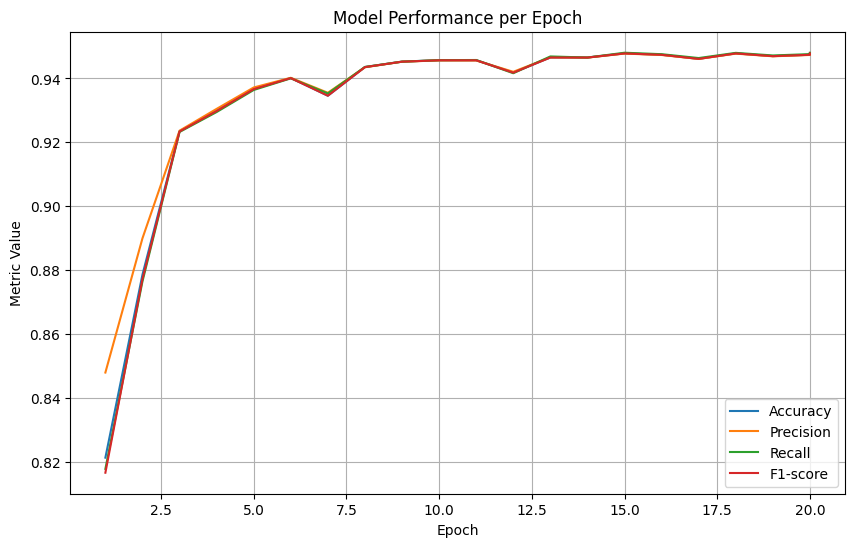

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# ambil log hasil training
log_history = pd.DataFrame(trainer.state.log_history)

# filter epoch rows saja
epoch_logs = log_history[log_history["eval_loss"].notnull()].copy()
# Pastikan urut berdasarkan epoch
epoch_logs = epoch_logs.sort_values(by="epoch")

# tampilkan isi
print(epoch_logs[['epoch', 'loss', 'eval_loss', 'eval_accuracy', 'eval_f1', 'eval_precision', 'eval_recall']])

# plot semua metrik utama
plt.figure(figsize=(10, 6))
plt.plot(epoch_logs["epoch"], epoch_logs["eval_accuracy"], label="Accuracy")
plt.plot(epoch_logs["epoch"], epoch_logs["eval_precision"], label="Precision")
plt.plot(epoch_logs["epoch"], epoch_logs["eval_recall"], label="Recall")
plt.plot(epoch_logs["epoch"], epoch_logs["eval_f1"], label="F1-score")
# plt.plot(epoch_logs["epoch"], epoch_logs["eval_loss"], label="Validation Loss")

plt.title("Model Performance per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Metric Value")
plt.legend()
plt.grid(True)
plt.show()


In [13]:
# -------------------------------
# 9. Save the Fine-tuned Model
# -------------------------------
save_path = "/kaggle/working/indobertweet_finetuned_judol"
trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)
print(f"\n✅ Model fine-tuned and saved to: {save_path}")



✅ Model fine-tuned and saved to: /kaggle/working/indobertweet_finetuned_judol


In [14]:
import shutil

save_path = "/kaggle/working/indobertweet_finetuned_judol"
zip_path = "/kaggle/working/indobertweet_finetuned_judol.zip"

# Compress the entire folder
shutil.make_archive(zip_path.replace('.zip', ''), 'zip', save_path)

print(f"✅ Model zipped and ready for download: {zip_path}")

✅ Model zipped and ready for download: /kaggle/working/indobertweet_finetuned_judol.zip
